# Infectivity, Neutralization, Binding, and Modeling

In [45]:
import pandas as pd
import torch
import re
import pickle
import numpy as np
from tqdm import tqdm

from sklearn.neighbors import KernelDensity as KDE

import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pyro.set_rng_seed(0)

d = torch.float32
torch.set_default_dtype(d)

run_MCMC = False

## Infectivity

#### Read in data
Infectivity data has relative infectivity normalized to WuG per panel. This data has been curated by Noor as a subset of a dataset produced by Javier and Ann. Noor's dataset was originally sent to me in a slack message.

The mutation data can be found [here](https://docs.google.com/spreadsheets/d/1L7WApdJDvrNnAbaGLaevyKmGDlOwgIrDA18FuuWadbY/edit#gid=0), though I have manually edited it in the following ways:
1. Remove noncanonical constructs
2. Add WuD rows (no mutations)

In [6]:
def parse_mutation_names(df):
    round_pattern = re.compile(r'\s*R[0-9]')    # R1-2_6, R1.2-6, not B.1
    accID_pattern = re.compile(r'\s*[0-9]{8}')    # 18846520
    voc_pattern1 = re.compile(r'\s*[A-Z]{1,3}(\.\d+)+')    # XBB.1.6, BA.4, not BQ
    voc_pattern2 = re.compile(r'\s*[a-zA-Z^R]{2}[a-zA-Z^R]*')   # alpha, Delta, BA, not R1-2
        
    df['Name'] = df['Name'].apply(lambda x: x.capitalize() if x.islower() else x)
    
    df = df[df['Name'].apply(lambda x: not re.match(round_pattern, x))]   # filter out all the round constructs
    df['Strain'] = df['Name'].apply(lambda x: re.search(voc_pattern1, x)[0] if re.search(voc_pattern1, x) else x)
    df['Strain'] = df['Strain'].apply(lambda x: x if re.match(voc_pattern1, x) else re.search(voc_pattern2, x)[0] if re.search(voc_pattern2, x) else None)
    df['Accession ID'] = df['Name'].apply(lambda x: re.search(accID_pattern, x)[0] if re.search(accID_pattern, x) else None)
    
    return df

def parse_infectivity_names(df):
    accID_pattern = re.compile(r'[0-9]{8}')    # 18846520
    voc_pattern1 = re.compile(r'\s*[A-Z]{1,3}(\.\d+)+')    # XBB.1.6, BA.4, not BQ
    voc_pattern2 = re.compile(r'\s*[a-zA-Z^R]{2}[a-zA-Z^R]*')   # alpha, Delta, BA, not R1-2
    
    df['Name'] = df['Name'].apply(lambda x: x.capitalize() if x.islower() else x)
    
    df['Strain'] = df['Name'].apply(lambda x: re.search(voc_pattern1, x)[0] if re.search(voc_pattern1, x) else x)
    df['Strain'] = df['Strain'].apply(lambda x: x if re.match(voc_pattern1, x) else re.search(voc_pattern2, x)[0] if re.search(voc_pattern2, x) else None)
    df['Accession ID'] = df['Name'].apply(lambda x: re.search(accID_pattern, x)[0] if re.search(accID_pattern, x) else None)
    
    return df

In [11]:
infectivity.columns

Index(['Name', 'replicate 1', 'replicate 2', 'replicate 1.1', 'rel_inf',
       'Strain', 'Accession ID', 'All mutations'],
      dtype='object')

In [12]:
# Infectivity
filename = 'infectivity_summary_variants_fin.csv'
infectivity = pd.read_csv(filename).drop_duplicates()
infectivity = parse_infectivity_names(infectivity)

original_count = len(infectivity)
original_strains = infectivity['Name'].unique()

# Mutations
filename = 'construct_order_mutations.csv'
mutations = pd.read_csv(filename, usecols=['Name', 'All mutations']).drop_duplicates()
mutations = parse_mutation_names(mutations)

# def catch_strains(set1, set2):
#     set1, set2 = set(set1), set(set2)
#     missed = set(s for s in set1 if s not in set2)
#     symdif = set1 ^ set2 
#     print(f'{len(missed)} strains not in set 2:')
#     for s in missed:
#         print(f'\t{s}')
#     print(f'{len(symdif)} strains not common to both sets')
    
# catch_strains(infectivity['Name'].unique(), mutations['Name'].unique())

infectivity = pd.merge(infectivity, mutations, on=['Strain', 'Accession ID'], suffixes=('', ' (order form)'))
infectivity = infectivity.drop(columns=['Name (Luban lab)', 'Name (order form)'])
print(f'{len(infectivity)} strains to analyze')
print(f'Strains lost: {original_count - len(infectivity)}')
lost_strains = set(original_strains) - set(infectivity['Name'].unique())
for s in lost_strains:
    print(f'\t{s}')
print('Note: we removed No Spike Control and two XBB noncon sequences from the mutation file manually, so we may see this reflected  in the lost sequences')

39 strains to analyze
Strains lost: 3
	XBB.1 (EPI_ISL_15469817)
	XBB (EPI_ISL_15469817)
	No Spike Control
Note: we removed No Spike Control and two XBB noncon sequences from the mutation file manually, so we may see this reflected  in the lost sequences


C:\Users\blk18\AppData\Local\Temp\ipykernel_884\599384048.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Strain'] = df['Name'].apply(lambda x: re.search(voc_pattern1, x)[0] if re.search(voc_pattern1, x) else x)
C:\Users\blk18\AppData\Local\Temp\ipykernel_884\599384048.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Strain'] = df['Strain'].apply(lambda x: x if re.match(voc_pattern1, x) else re.search(voc_pattern2, x)[0] if re.search(voc_pattern2, x) else None)
C:\Users\blk18\AppData\Local\

#### Regress infectivity over mutations

In [50]:
# Create X and Y variables
def one_hot(df, comma_sep_col):
    features = list(set(','.join(df[comma_sep_col].tolist()).split(',')))
    onehot = [[1 if mut.strip() in muts else 0 for mut in features] for muts in df[comma_sep_col]]
    
    return torch.tensor(onehot, dtype=d), features

wug_references = infectivity[['Name', 'replicate 1', 'replicate 2', 'replicate 1.1', 'All mutations']].dropna()

X, labels = one_hot(wug_references, 'All mutations')
Y = torch.tensor(wug_references[['replicate 1', 'replicate 2', 'replicate 1.1']].values, dtype=d)

assert Y.shape[0] == X.shape[0], 'Dimension mismatch between X and Y'

In [14]:
# Model
def model(X,Y):
    # Y might have one or multiple obervations for each construct -
    # let's make sure the shape is consistent
    if len(Y.shape)==1:
        Y = Y.unsqueeze(-1)
    
    # Set hyperparameters
    # μ_m = pyro.sample('μ_m', dist.Normal(0.,1.))
    # σ_m = pyro.sample('σ_m', dist.HalfNormal(1.))
    # μ_b = pyro.sample('μ_b', dist.Normal(1.,1.))
    # σ_b = pyro.sample('σ_b', dist.HalfNormal(1.))
    μ_m = 0.
    σ_m = 1.
    μ_b = 1.
    σ_b = 1.
    
    σ = 1.
    
    # Sample mutation contribution for each mutation
    with pyro.plate("mutations", X.shape[1]):
        m = pyro.sample("m", dist.Normal(μ_m, σ_m))
    
    # Sample baseline for each construct (may want to do this for each background, not sure yet)
    # with pyro.plate("constructs", X.shape[0]):
    b = pyro.sample("b", dist.Normal(μ_b, σ_b))
    
    # Predict infectivity
    pred_infectivity = torch.matmul(X,m) + b
    
    # Score observations
    with pyro.plate("data", X.shape[0]):
        return pyro.sample("obs", dist.Normal(pred_infectivity, σ), obs=torch.transpose(Y,0,1))


In [34]:
chain_file = 'mcmc_chain.pkl'
features_file = 'mcmc_features.txt'

if run_MCMC:
    nuts_kernel = NUTS(model)

    mcmc = MCMC(nuts_kernel, num_samples=2000, warmup_steps=2000)
    mcmc.run(X, Y)

    posterior_samples = mcmc.get_samples()

    # Save
    with open(chain_file, 'wb') as f:
        pickle.dump(posterior_samples, f)

    with open(features_file, 'w') as f:
        f.writelines(labels)
        
else:
    with open(chain_file, 'rb') as f:
        posterior_samples = pickle.load(f)
    
    with open(features_file, 'r') as f:
        labels = f.read().split('\n')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
C:\Users\blk18\AppData\Local\Temp\ipykernel_14064\994820963.py:13: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
C:\Users\blk18\AppData\Roaming\Python\Python310\site-packages\IPython\core\events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
C:\Users\blk18\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


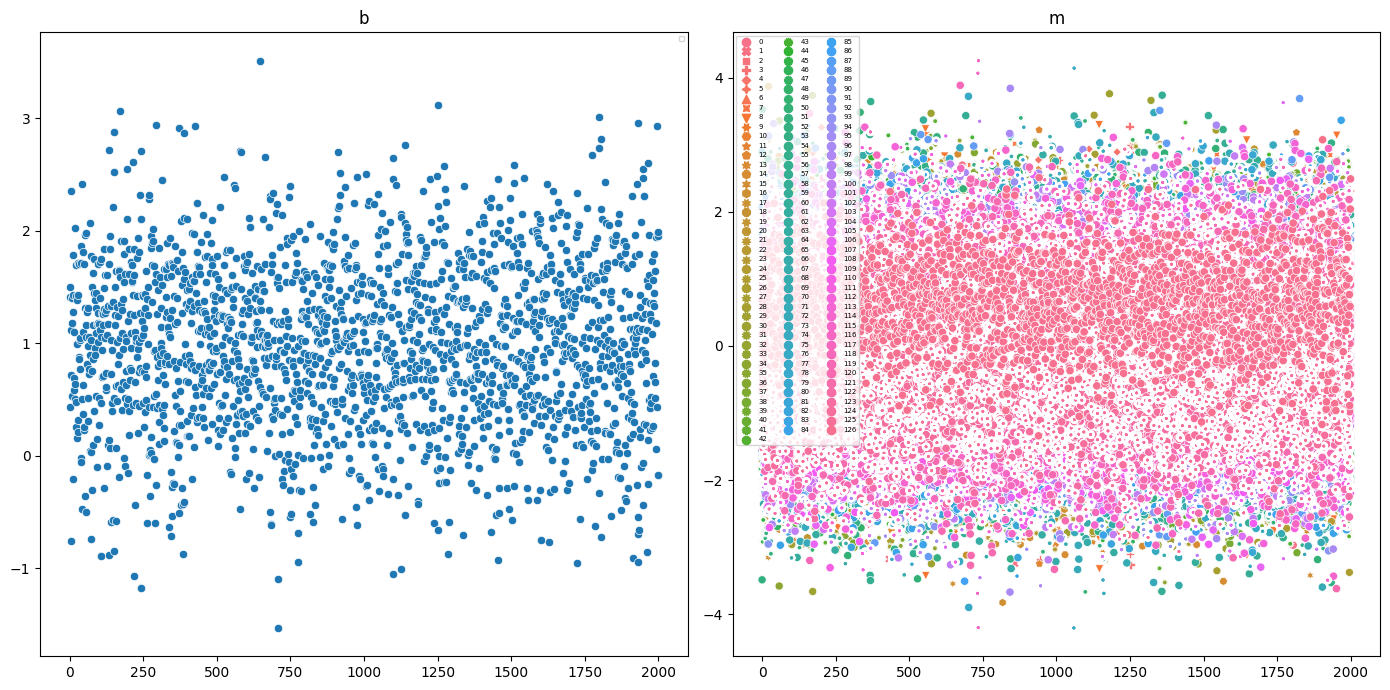

In [7]:
def sns_trace(samples):
    num_trace = len(samples.keys())
    
    fig, axes = plt.subplots(int(num_trace/2), 2, figsize=(14, 7))
    axes = axes.flatten()
    
    for key, ax in zip(samples.keys(),axes):
        trace = samples[key]
        sns.scatterplot(trace.detach().numpy(), ax=ax)
        ax.set_title(key)
        ax.legend(ncol=3, fontsize=5)
        
        fig.tight_layout()
        
sns_trace(posterior_samples)

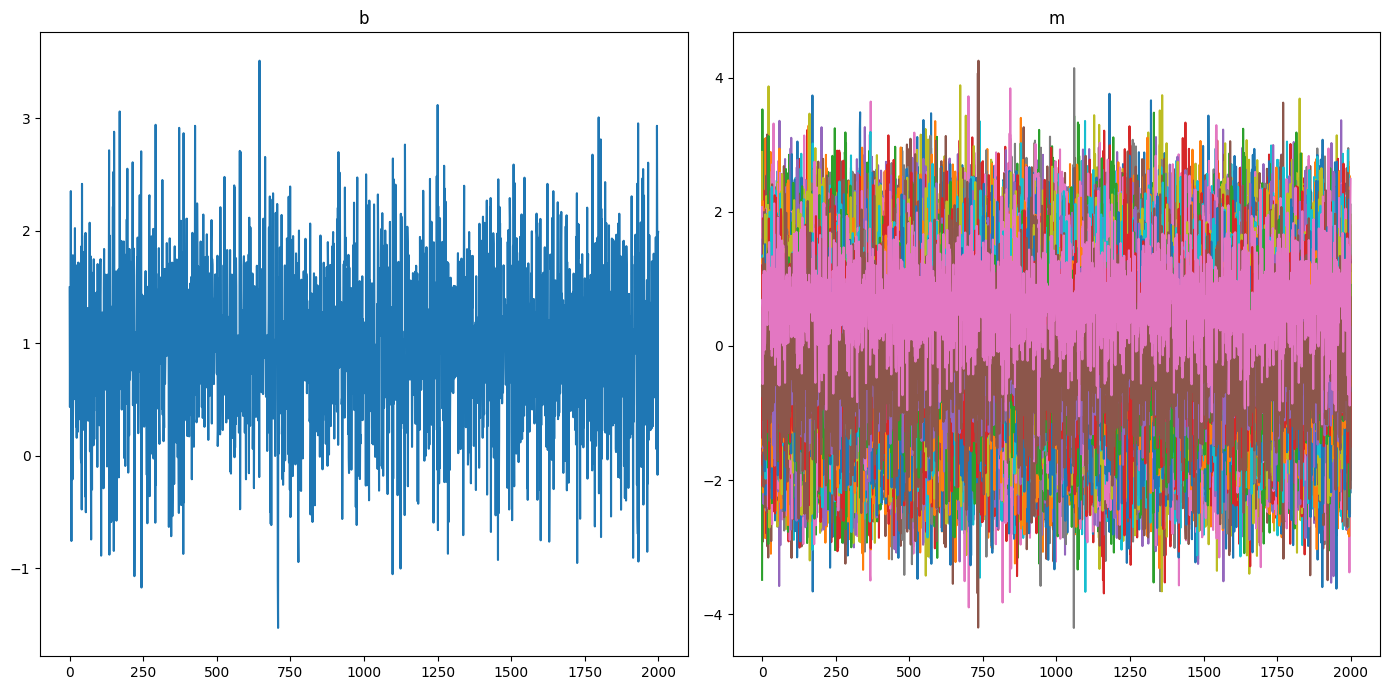

In [8]:
def plot_trace(samples):
    num_trace = len(samples.keys())
    
    fig, axes = plt.subplots(int(num_trace/2), 2, figsize=(14, 7))
    axes = axes.flatten()
    
    for key, ax in zip(samples.keys(),axes):
        trace = samples[key]
        ax.plot(trace.detach().numpy())
        ax.set_title(key)
        # ax.legend(ncol=3, fontsize=5)
        
        fig.tight_layout()
        
plot_trace(posterior_samples)

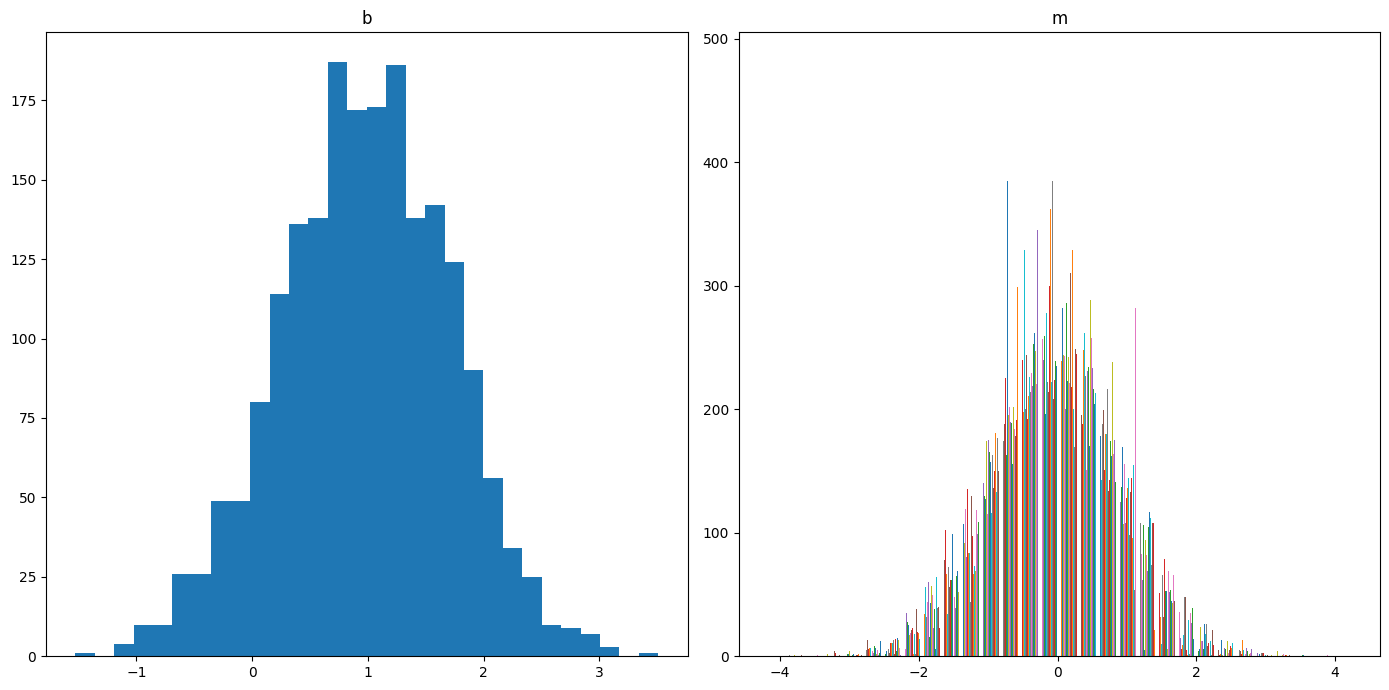

In [9]:
def hist_trace(samples):
    num_trace = len(samples.keys())
    
    fig, axes = plt.subplots(int(num_trace/2), 2, figsize=(14, 7))
    axes = axes.flatten()
    
    for key, ax in zip(samples.keys(),axes):
        trace = samples[key]
        ax.hist(trace.detach().numpy(), bins=30)
        ax.set_title(key)
        # ax.legend(ncol=3, fontsize=5)
        
        fig.tight_layout()
        
hist_trace(posterior_samples)

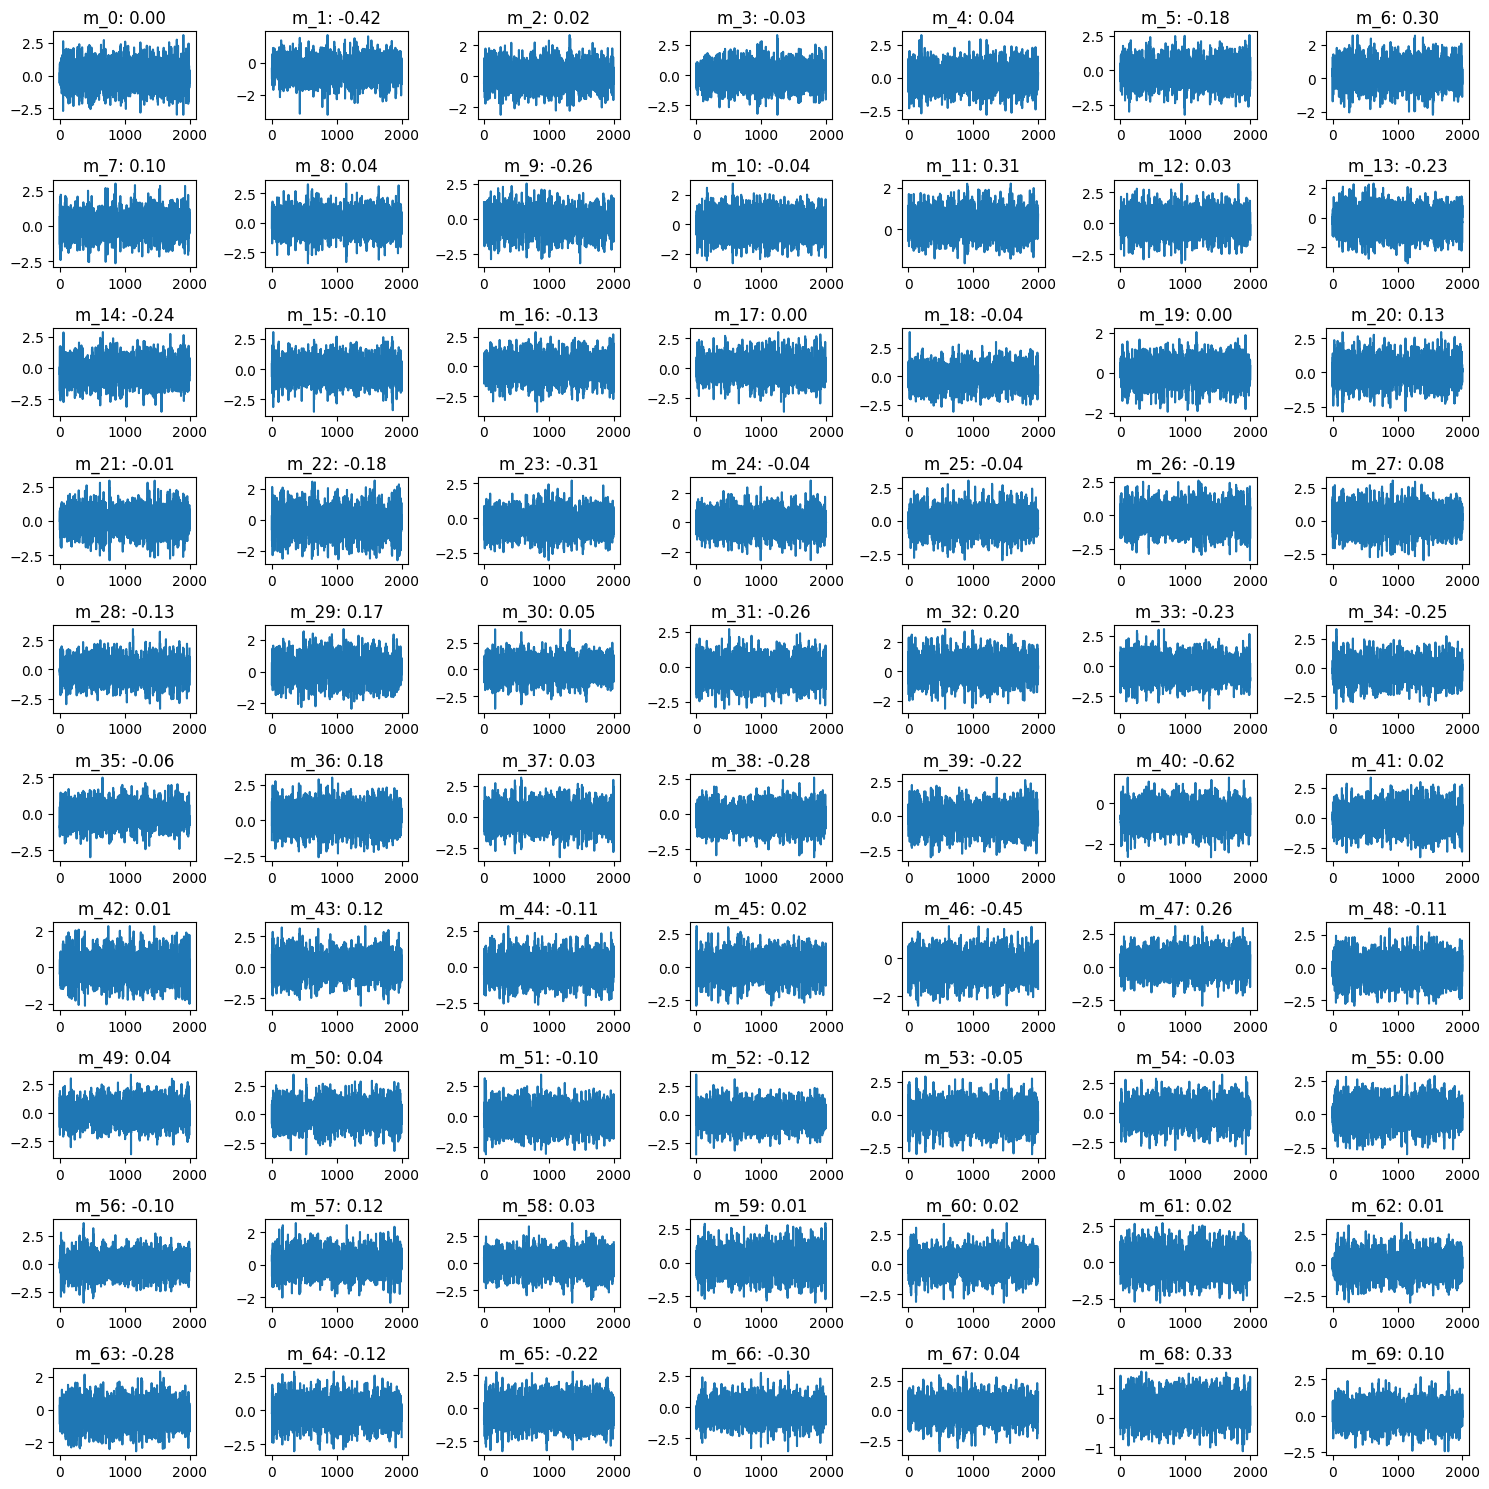

In [10]:
def plot_m(mtrace, style='hist'):
    num_m = 70
    
    fig, axes = plt.subplots(10, 7, figsize=(15,15))
    axes = axes.flatten()
    
    for i, ax in enumerate(axes):
        t = mtrace[:,i]
        if style=='hist':
            ax.hist(t)
        elif style=='trace':
            ax.plot(t)
        ax.set_title('m_{}: {:2.2f}'.format(i, t.mean()))
    
    fig.tight_layout()
    
plot_m(posterior_samples['m'], style='trace')

In [15]:
m_samples = posterior_samples['m']
b_samples = posterior_samples['b']
all_samples = torch.cat((m_samples, b_samples.reshape(-1,1)), dim=1)  # put β at the end
all_samples.shape

torch.Size([2000, 128])

In [18]:
all_samples.mean(dim=0).shape

torch.Size([128])

In [105]:
def preprocess_kde(samples, labels):
    m_samples = samples['m']
    b_samples = samples['b']
    all_samples = torch.cat((m_samples, b_samples.reshape(-1,1)), dim=1)  # put β at the end
    coefficients = labels.copy()
    sort_by = all_samples.mean(dim=0)
    sort_by = sort_by[:-1]  # intercept is the last term in this tensor
    coef_map = {x:i for i, (_,x) in enumerate(sorted(zip(sort_by, labels), reverse=True))}
    # Add intercept term last
    coefficients.append('Baseline (WuD)')
    coef_map['Baseline (WuD)'] = len(coefficients)-1
    return all_samples, coefficients, coef_map

def setup(fig, axes, samples):
    options = {}
    options['scale'] = 1
    options['xlim'] = [-3, 3]
    options['ymax'] = samples.shape[1]
    
    axes[1].spines.right.set_visible(False)
    axes[1].spines.left.set_visible(False)
    axes[1].spines.top.set_visible(False)
    axes[1].set_yticks([])
    axes[1].set_yticklabels([])
    
    axes[0].axis('off')
    axes[2].axis('off')
    
    plt.rcParams['font.family'] = ['Times New Roman']
    return options

def plot_kdes(ax, samples, coefficients, coef_map, options):
    scale = options['scale']
    ymax = options['ymax']
    xlim = options['xlim']
    num_points = 1000
    color='blue'
    
    linecolor = 'blue'
    linewidth = 0.7
    
    for i, coef in tqdm(enumerate(coefficients)):
        base_y = (ymax - coef_map[coef])  # coef_map[coef]  
        sample_idx = i
        # Fit KDE
        s = samples[:, sample_idx]
        kde = KDE(kernel='gaussian', bandwidth=0.01).fit(s.reshape(-1,1))
        x = np.linspace(xlim[0], xlim[1], num_points).reshape(-1,1)
        # Generate KDE curve
        y = np.exp(kde.score_samples(x))
        # Scale curve
        y /= (scale*max(y))
        # Move y up to the desired height
        y += base_y
        
        
        ax.plot(x, y, 
                color=color, linewidth=linewidth)
        
    ax.set_xlim(xlim)
    ax.set_ylim([0, options['ymax']+1])
    ax.set_title('Posterior', loc='center')
    
    
def annotate_posterior(ax, coefficients, coef_map, options):
    scale = options['scale']
    ymax = options['ymax']
    fontsize = 8
    
    pos = [ymax - i for i in range(ymax)]
    labels = list(coef_map.keys())
    for y, t in zip(pos, labels):
        ax.text(1, y, t,
                ha='right')
        
    ax.set_xlim([0,1])
    ax.set_ylim([0, options['ymax']+1])
    ax.set_title('Mutations', loc='right')
    
def annotate_means(ax, samples, coefficients, coef_map, options):
    scale = options['scale']
    ymax = options['ymax']
    fontsize = 8
    
    coefs = list(coef_map.keys())
    for i, c in enumerate(coefficients):
        mean = samples[:,i].mean()
        t = '{:6.2f}'.format(mean)
        y = ymax - coef_map[c]
        ax.text(0, y, t,
                ha='left')
        
    ax.set_xlim([0,1])
    ax.set_ylim([0, options['ymax']+1])
    ax.set_title('Means', loc='left')

128it [00:10, 11.87it/s]


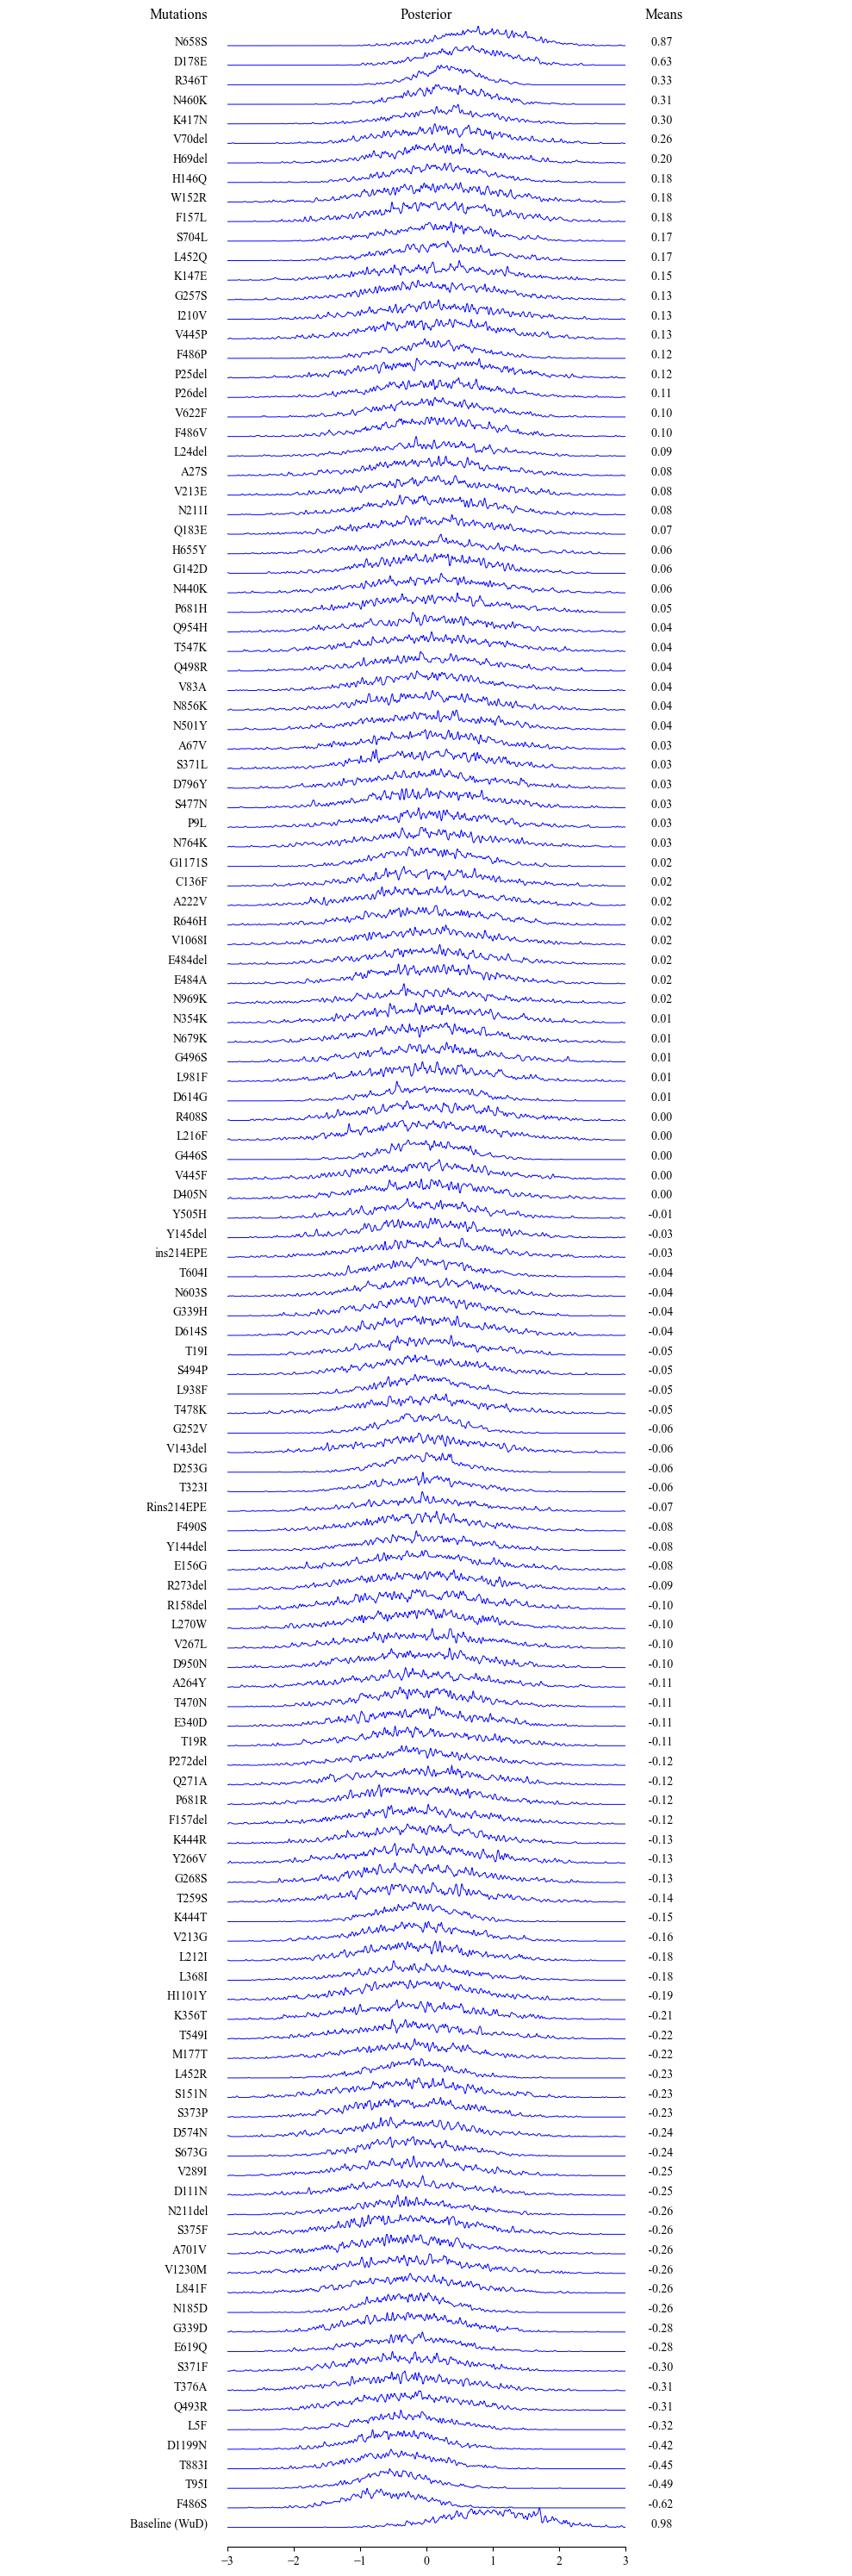

In [106]:
all_samples, coefficients, coefficient_map = preprocess_kde(posterior_samples, labels)

fig, axes = plt.subplots(1, 3, figsize=(10, 30), gridspec_kw={'width_ratios': [1, 2, 1]})

options = setup(fig, axes, all_samples)
plot_kdes(axes[1], all_samples, coefficients, coefficient_map, options)
annotate_posterior(axes[0], coefficients, coefficient_map, options)
annotate_means(axes[2], all_samples, coefficients, coefficient_map, options)


fig.tight_layout()
fig.savefig('posterior_with_annotations.png', dpi=150)

In [62]:
# Create a CSV with results
outfile = 'mutation_effects.csv'
df = pd.DataFrame({'Mutation':coefficients, 'Mean':all_samples.mean(dim=0), 'Std':all_samples.std(dim=0)})
df.to_csv(outfile, index=False)